# 1

## (a) What does it mean for two sentences to have similar meaning?

Two sentences have similar meaning when they communicate similar ideas, events, or concepts, even if they use different words. For example, they may describe the same object, action, or situation.

A few possible ways to think about semantic similarity:

1. Same event or situation: Two sentences describe essentially the same thing happening.
2. Related concepts or topics: Two sentences are about similar subjects, such as food, weather, animals, etc.
3. Similar implications: Even if the wording differs, the reader would understand them as conveying related information.


## (b) Intuitive grouping of the six sentences

Sentences:

1. The dog barked loudly.
2. A loud noise came from the dog.
3. She baked a cake.
4. He cooked dinner.
5. The sky is blue.
6. The clouds are dark.

### Group 1: Dog / sound sentences

- The dog barked loudly.
- A loud noise came from the dog.

These are the most semantically similar because both involve a dog producing a loud sound. The second sentence does not explicitly say “barked,” but it strongly implies a similar event.

### Group 2: Cooking / food sentences

- She baked a cake.
- He cooked dinner.

These are similar because both involve preparing food. They differ in the specific food and action, but both are about cooking or making a meal.

### Group 3: Sky / weather sentences

- The sky is blue.
- The clouds are dark.

These are related because both describe things in the sky or weather-related visual conditions. However, they are not as close in meaning as the dog sentences, because one describes a clear blue sky while the other may suggest cloudy or stormy weather.

## (c) Sentence embeddings and cosine similarity
The sentence embedding model `sentence-transformers/all-MiniLM-L6-v2` is used to encode each sentence as a vector. Each sentence becomes a point in a learned latent space, and cosine similarity measures how close the directions of two vectors are.

In [1]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

sentences = [
    "The dog barked loudly.",
    "A loud noise came from the dog.",
    "She baked a cake.",
    "He cooked dinner.",
    "The sky is blue.",
    "The clouds are dark."
]

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(
    similarity_matrix,
    index=[f"S{i+1}" for i in range(len(sentences))],
    columns=[f"S{i+1}" for i in range(len(sentences))]
)

print(df.round(3))

README.md: 0.00B [00:00, ?B/s]

       S1     S2     S3     S4     S5     S6
S1  1.000  0.718  0.070  0.118 -0.050  0.039
S2  0.718  1.000  0.143  0.186  0.043  0.094
S3  0.070  0.143  1.000  0.402  0.108  0.185
S4  0.118  0.186  0.402  1.000  0.107  0.118
S5 -0.050  0.043  0.108  0.107  1.000  0.433
S6  0.039  0.094  0.185  0.118  0.433  1.000


Where:

| Label | Sentence                        |
|-------|---------------------------------|
| S1    | The dog barked loudly.          |
| S2    | A loud noise came from the dog. |
| S3    | She baked a cake.               |
| S4    | He cooked dinner.               |
| S5    | The sky is blue.                |
| S6    | The clouds are dark.            |

### Highest similarity pair

The highest non-identical similarity score is:

- S1: “The dog barked loudly.”
- S2: “A loud noise came from the dog.”

These sentences have the strongest semantic overlap because they both describe a dog making a loud sound.

### Lowest similarity pair

The lowest similarity score in this example is:

- S4: “He cooked dinner.”
- S5: “The sky is blue.”

These are not closely related. One is about preparing food, while the other is about the color of the sky.

### Comparison with initial intuition

The embedding results mostly match my initial grouping. The dog sentences are closest, the cooking-related sentences are also relatively close, and the sky/cloud sentences show moderate similarity. Sentences from unrelated categories, such as cooking and sky descriptions, have much lower similarity scores.

## (d) Short response on embedding space

When two sentences are close together in embedding space, it means the model represents them as having similar semantic content. In other words, the model has learned that the sentences are related in meaning, topic, or implication.

The model seems to capture broad meaning well, such as shared topics and related events. For example, it recognizes that barking and loud noise from a dog are related, even though the wording is different. It also groups food preparation sentences together and sky/weather descriptions together.

However, embeddings may not always capture fine nuance perfectly. For example, “The sky is blue” and “The clouds are dark” are both related to the sky, but they describe different visual conditions and possibly different weather. A model may mark them as similar because of the shared topic, even though their emotional or situational implications are different. Embeddings can also struggle with sarcasm, negation, metaphor, or subtle differences in intent.

## (e) Reducing embeddings to two dimensions and plotting

To visualize the sentence embeddings, I reduced them to two dimensions using PCA or t-SNE. PCA is often useful for a small number of points because it is deterministic and simple. t-SNE can also be used, but with only six sentences, its structure should be interpreted cautiously.

### Example using PCA

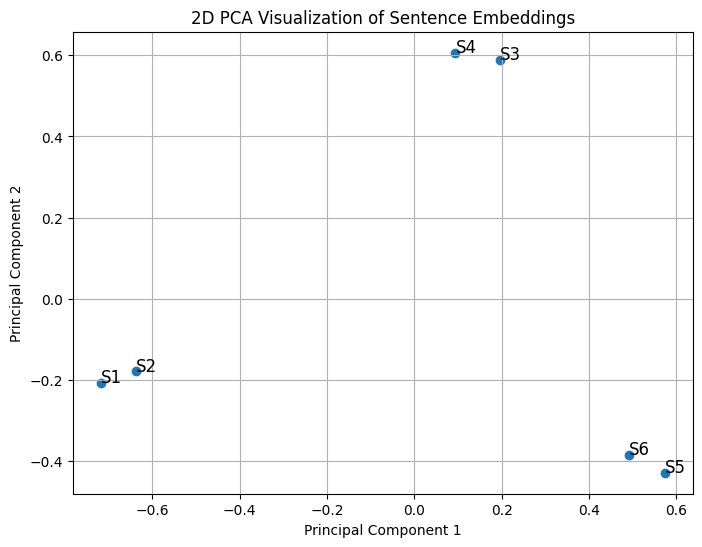

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sentences = [
    "The dog barked loudly.",
    "A loud noise came from the dog.",
    "She baked a cake.",
    "He cooked dinner.",
    "The sky is blue.",
    "The clouds are dark."
]

labels = ["S1", "S2", "S3", "S4", "S5", "S6"]

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, label in enumerate(labels):
    plt.annotate(label, (reduced[i, 0], reduced[i, 1]), fontsize=12)

plt.title("2D PCA Visualization of Sentence Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

### Example using t-SNE

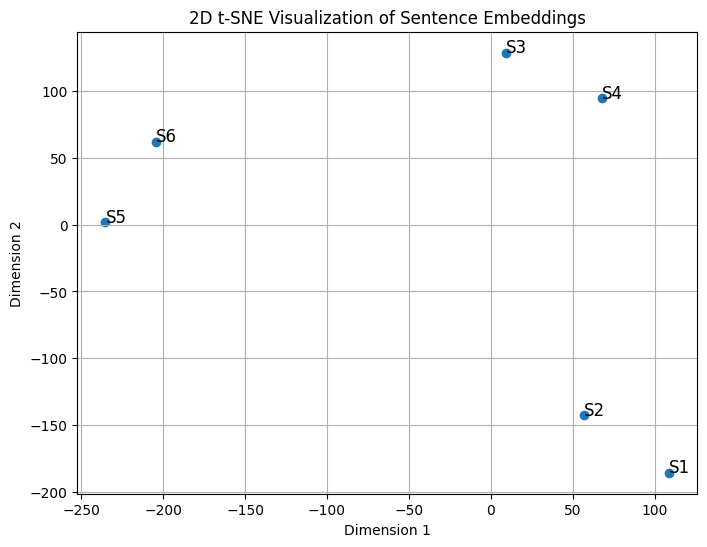

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

sentences = [
    "The dog barked loudly.",
    "A loud noise came from the dog.",
    "She baked a cake.",
    "He cooked dinner.",
    "The sky is blue.",
    "The clouds are dark."
]

labels = ["S1", "S2", "S3", "S4", "S5", "S6"]

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

tsne = TSNE(
    n_components=2,
    perplexity=2,
    random_state=42,
    init="random",
    learning_rate="auto"
)

reduced = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, label in enumerate(labels):
    plt.annotate(label, (reduced[i, 0], reduced[i, 1]), fontsize=12)

plt.title("2D t-SNE Visualization of Sentence Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

### Interpretation of the visualization

The visualization should show sentences with similar meanings appearing closer together. The two dog-related sentences should form a close cluster. The two food-related sentences should also appear near each other, and the two sky/weather-related sentences may appear as another small cluster.

This suggests that the model organizes sentence meaning according to semantic features such as topic, action, and objects involved. Sentences about dogs and sounds are placed near each other, food preparation sentences are near each other, and sky/weather sentences are grouped separately. The plot is a simplified 2D view of a much higher-dimensional latent space, so it should not be treated as a perfect map, but it gives an intuitive picture of how the model represents meaning.

# 2

Dataset:

$$
X = \{[1,2], [2,3], [3,4], [4,5]\}
$$

We are given a simple 2-to-1-to-2 linear autoencoder:

### Encoder

$$
z = 0.5x_1 + 0.5x_2
$$

### Decoder

$$
\hat{x}_1 = 0.6z
$$

$$
\hat{x}_2 = 0.4z
$$

The reconstruction error is:

$$
MSE = \frac{1}{2}\sum_i (x_i - \hat{x}_i)^2
$$

---

## (a) Train or inspect a simple autoencoder

We compute the latent code $z$, reconstruction $\hat{x}$, and reconstruction error.

---

### Input 1: $[1,2]$

#### Latent code

$$
z = 0.5(1) + 0.5(2)
$$

$$
z = 0.5 + 1 = 1.5
$$

#### Reconstruction

$$
\hat{x}_1 = 0.6(1.5) = 0.9
$$

$$
\hat{x}_2 = 0.4(1.5) = 0.6
$$

So,

$$
\hat{x} = [0.9, 0.6]
$$

#### Reconstruction error

$$
MSE = \frac{1}{2}[(1 - 0.9)^2 + (2 - 0.6)^2]
$$

$$
MSE = \frac{1}{2}[(0.1)^2 + (1.4)^2]
$$

$$
MSE = \frac{1}{2}[0.01 + 1.96]
$$

$$
MSE = \frac{1}{2}(1.97)
$$

$$
MSE = 0.985
$$

---

### Input 2: $[2,3]$

#### Latent code

$$
z = 0.5(2) + 0.5(3)
$$

$$
z = 1 + 1.5 = 2.5
$$

#### Reconstruction

$$
\hat{x}_1 = 0.6(2.5) = 1.5
$$

$$
\hat{x}_2 = 0.4(2.5) = 1.0
$$

So,

$$
\hat{x} = [1.5, 1.0]
$$

#### Reconstruction error

$$
MSE = \frac{1}{2}[(2 - 1.5)^2 + (3 - 1.0)^2]
$$

$$
MSE = \frac{1}{2}[(0.5)^2 + (2.0)^2]
$$

$$
MSE = \frac{1}{2}[0.25 + 4.00]
$$

$$
MSE = \frac{1}{2}(4.25)
$$

$$
MSE = 2.125
$$

---

### For all four points

| Input $x$ | Latent code $z = 0.5x_1 + 0.5x_2$ | Reconstruction $\hat{x} = [0.6z, 0.4z]$ | MSE |
|---|---:|---|---:|
| $[1,2]$ | $1.5$ | $[0.9, 0.6]$ | $0.985$ |
| $[2,3]$ | $2.5$ | $[1.5, 1.0]$ | $2.125$ |
| $[3,4]$ | $3.5$ | $[2.1, 1.4]$ | $3.785$ |
| $[4,5]$ | $4.5$ | $[2.7, 1.8]$ | $5.965$ |

---

### Checking the remaining two errors

For $[3,4]$:

$$
z = 0.5(3) + 0.5(4) = 3.5
$$

$$
\hat{x} = [0.6(3.5), 0.4(3.5)] = [2.1, 1.4]
$$

$$
MSE = \frac{1}{2}[(3 - 2.1)^2 + (4 - 1.4)^2]
$$

$$
MSE = \frac{1}{2}[0.81 + 6.76] = 3.785
$$

For $[4,5]$:

$$
z = 0.5(4) + 0.5(5) = 4.5
$$

$$
\hat{x} = [0.6(4.5), 0.4(4.5)] = [2.7, 1.8]
$$

$$
MSE = \frac{1}{2}[(4 - 2.7)^2 + (5 - 1.8)^2]
$$

$$
MSE = \frac{1}{2}[1.69 + 10.24] = 5.965
$$

---

## (b) Interpret the latent representation

The 1D latent variable $z$ preserves the average magnitude of the two input features, because:

$$
z = 0.5x_1 + 0.5x_2
$$

So, larger input points produce larger latent values. For example, $[1,2]$ maps to $z = 1.5$, while $[4,5]$ maps to $z = 4.5$.

However, information is lost because two numbers are compressed into only one number. The encoder does not separately preserve $x_1$ and $x_2$; it only keeps their average. For example, different inputs such as $[1,5]$ and $[3,3]$ would both produce:

$$
z = 3
$$

even though they are different points.

Reconstruction cannot be perfect because the 1D bottleneck is too narrow to store all possible 2D information. The decoder can only reconstruct points along a restricted line determined by $[0.6z, 0.4z]$. Therefore, unless the original data naturally lies on that exact line, reconstruction errors will occur.

---

## (c) Connect to the VAE idea

### In a VAE, what additional quantities are produced by the encoder besides a latent value?

In a variational autoencoder, the encoder does not produce just one fixed latent code $z$. Instead, it produces the parameters of a probability distribution over latent variables, usually:

$$
\mu
$$

and

$$
\sigma
$$

or more commonly:

$$
\mu
$$

and

$$
\log \sigma^2
$$

These represent the mean and variance of a Gaussian latent distribution:

$$
q(z|x) = \mathcal{N}(\mu, \sigma^2)
$$

Then a latent sample $z$ is drawn from that distribution, often using the reparameterization trick:

$$
z = \mu + \sigma \epsilon
$$

where:

$$
\epsilon \sim \mathcal{N}(0,1)
$$

---

### What does the KL term encourage?

The KL divergence term encourages the learned latent distribution $q(z|x)$ to stay close to a chosen prior distribution, usually a standard normal distribution:

$$
p(z) = \mathcal{N}(0, I)
$$

The VAE loss is commonly written as:

$$
\text{Loss} = \text{Reconstruction Loss} + KL(q(z|x) \| p(z))
$$

The reconstruction loss encourages the model to reproduce the input accurately, while the KL term regularizes the latent space. It encourages the latent codes to be smooth, continuous, and organized instead of scattered irregularly.

---

### Why is a VAE better suited than a vanilla AE for sampling new data points from the latent space?

A VAE is better suited for sampling because its latent space is explicitly trained to follow a known probability distribution, such as a standard normal distribution. This means we can sample a new latent point:

$$
z \sim \mathcal{N}(0, I)
$$

and pass it through the decoder to generate a new data point.

In a vanilla autoencoder, the latent space may be irregular or have gaps. Randomly sampling a latent value might land in a region that the decoder never saw during training, producing poor or meaningless outputs. A VAE reduces this problem by making the latent space smoother and more structured.

---

## (d) Optional: Changing the latent dimension from 1 to 2

If the latent dimension is changed from 1 to 2, reconstruction would generally improve because the bottleneck is no longer forcing two input dimensions into only one latent value. With a 2D latent space, the encoder can potentially preserve both original input coordinates.

For example, a simple 2D latent representation could be:

$$
z_1 = x_1
$$

$$
z_2 = x_2
$$

and the decoder could reconstruct:

$$
\hat{x}_1 = z_1
$$

$$
\hat{x}_2 = z_2
$$

In that case, reconstruction could be perfect:

$$
\hat{x} = x
$$

So, increasing the latent dimension from 1 to 2 improves reconstruction because less information is lost during compression. However, it also reduces the amount of compression, which means the autoencoder may simply learn to copy the input instead of learning a compact representation.

# 3

The goal is to train a simple GAN that learns to generate 2D points resembling two clusters centered near $(-2,0)$ and $(2,0)$.

## (a) Generate a toy dataset
### Dataset: Two Gaussian Clusters

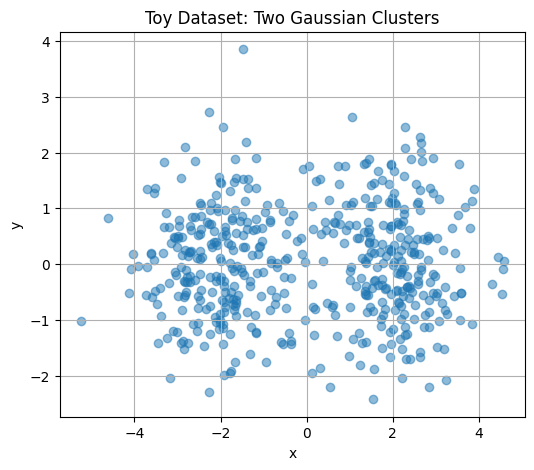

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 250
cluster1 = np.random.randn(n, 2) + [-2, 0]
cluster2 = np.random.randn(n, 2) + [2, 0]
data = np.vstack([cluster1, cluster2])

plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5)
plt.title("Toy Dataset: Two Gaussian Clusters")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

### Expected visualization

The real data should appear as two main clouds of points:

* one cluster centered around $(-2,0)$
* one cluster centered around $(2,0)$

There may be some overlap between the clusters because each cluster is sampled from a Gaussian distribution.

## (b) Train a simple GAN
The architecture is:
* Generator: random noise vector $\rightarrow$ 2D fake point
* Discriminator: 2D point $\rightarrow$ probability that point is real

## (c) Observe the results
After training, the generated samples should ideally form two clouds of points near the same locations as the real data.
Example observations

Early in training, generated points may be scattered randomly and may not resemble the two-cluster structure.
After training for several epochs, the generated points should move closer to the real data distribution.
The GAN may learn both clusters, but sometimes it may produce too many samples in one cluster or blur the space between the clusters.

### Example figure description
The final plot should show:

* Real data as one color, forming two Gaussian-like clusters.
* Generated data as another color, ideally overlapping with both real clusters.
* If training is successful, fake samples appear near $(-2,0)$ and $(2,0)$, rather than being uniformly scattered.



## (d) Reflection
In this example, the GAN partially learned the distribution if the generated points appear near the two real Gaussian clusters. If the generated samples cover both the left and right clusters, then the generator has learned the main structure of the data distribution reasonably well.

However, GAN training can be unstable. If the plot shows generated points only around one cluster, that would be an example of mode collapse, because the generator learned only one mode of the data distribution and ignored the other. If the generated points are spread in a line or scattered far away from the real clusters, that suggests the discriminator and generator did not reach a useful balance during training.

A successful result would show generated samples overlapping both clusters with a similar spread to the real data, while an unsuccessful result would show missing clusters, overly concentrated points, or unrealistic points between or outside the real clusters.